三维MRI数据形状：(128, 128, 30) → 通常为 (H, W, D) 或 (x, y, z)
第三维度大小：30，中间切片索引：15
切片原始值范围：min=0.0, max=221.0, mean=10.5653076171875


/tmp/ipykernel_332348/1619161913.py:95: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_332348/1619161913.py:95: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gyl/.conda/envs/dinov3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gyl/.conda/envs/dinov3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


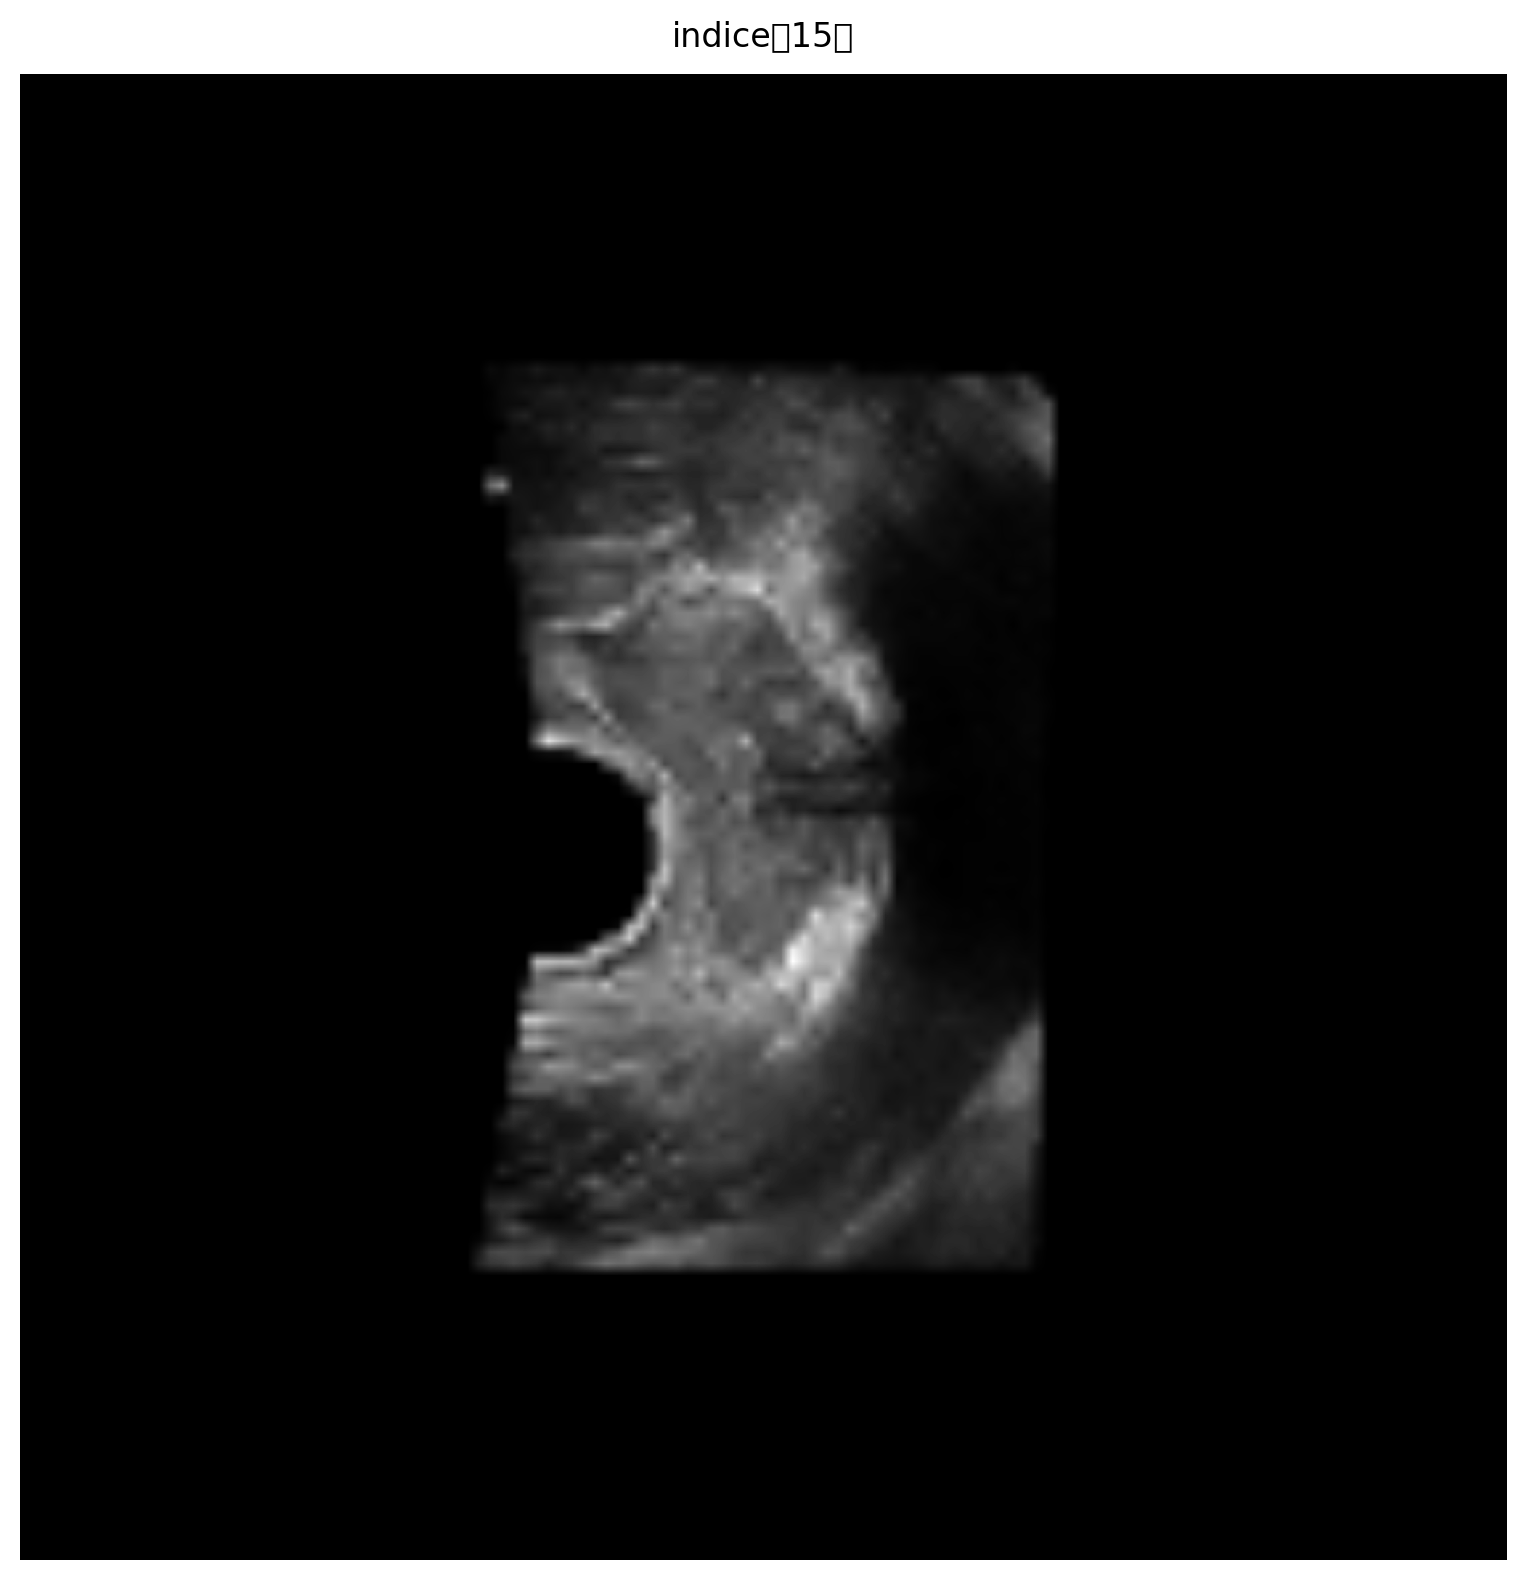

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib  # 用于读取 .nii.gz 文件
from torchvision import transforms


# --------------------------
# 1. 读取 .nii.gz 格式的三维MRI数据
# --------------------------
# 三维MRI文件路径（替换为你的文件路径）
mri_path = '/home/gyl/DataSets/dataset/test/fixed_images/case_0301_01.nii.gz'
# mri_path = '/home/gyl/DataSets/muProReg_process/val/us_images/case000000.nii.gz'

# 读取NIfTI文件
nifti_img = nib.load(mri_path)
# 提取三维数据数组（形状通常为 (H, W, D) 或 (D, H, W)，取决于扫描方向）
mri_3d = nifti_img.get_fdata()  # 转换为numpy数组，float64格式

# 查看三维数据形状，确认各维度含义
print(f"三维MRI数据形状：{mri_3d.shape} → 通常为 (H, W, D) 或 (x, y, z)")


# --------------------------
# 2. 确定第三维度并提取中间切片
# --------------------------
# 假设"第三维度"指深度维度（D），对应形状中的最后一个轴（根据实际数据调整）
# 若你的数据维度顺序为 (D, H, W)，则第三维度是第0轴，需修改 axis=0
third_dim_axis = -1  # 最后一个轴作为第三维度（D）
third_dim_size = mri_3d.shape[third_dim_axis]  # 第三维度的大小（如128）
middle_idx = third_dim_size // 2  # 中间切片索引（如128→64）
print(f"第三维度大小：{third_dim_size}，中间切片索引：{middle_idx}")

# 提取第三维度的中间切片（二维数组，形状 (H, W)）
# 用np.take沿指定轴提取索引为middle_idx的切片
mri_slice = np.take(mri_3d, indices=middle_idx, axis=third_dim_axis)


# --------------------------
# 3. 数据预处理（适配MRI特性）
# --------------------------
def normalize_mri(img, clamp_min=None, clamp_max=None, mean=None, std=None):
    """归一化MRI切片（根据实际数据调整参数）"""
    # 转换为Tensor并增加通道维度 (1, H, W)
    img_tensor = torch.tensor(img).unsqueeze(0).float()

    # 钳位异常值（MRI信号范围通常与CT不同，需根据数据调整）
    if clamp_min is not None and clamp_max is not None:
        img_tensor = torch.clamp(img_tensor, min=clamp_min, max=clamp_max)

    # 标准化（若无统计值，用当前切片的均值和标准差）
    if mean is None:
        mean = img_tensor.mean()
    if std is None:
        std = img_tensor.std()
    return (img_tensor - mean) / (std + 1e-8)


def make_transform(resize_size: int = 2048):
    """调整切片大小（保持与原逻辑一致）"""
    return transforms.Compose([
        transforms.Resize((resize_size, resize_size), antialias=True)
    ])


# 预处理切片（参数根据你的MRI数据调整，先查看数据范围）
print(f"切片原始值范围：min={mri_slice.min()}, max={mri_slice.max()}, mean={mri_slice.mean()}")
normalized_slice = normalize_mri(
    mri_slice,
    # clamp_min=0,       # 示例：根据上一行输出的min调整（如MRI可能在0-2000）
    # clamp_max=2000,    # 示例：根据上一行输出的max调整
    mean=None,         # 用切片自身均值（或替换为训练集统计值）
    std=None           # 用切片自身标准差
)

# 调整大小（如需匹配原CT的2048尺寸）
resize_size = 2048
resized_slice = make_transform(resize_size)(normalized_slice)  # 形状 (1, 2048, 2048)
resized_slice =resized_slice.repeat(3, 1, 1)

# --------------------------
# 4. 可视化中间切片
# --------------------------
plt.figure(figsize=(8, 8), dpi=200)
# 显示灰度图像（MRI常用gray colormap）
plt.imshow(
    resized_slice[0].numpy(),  # 去除通道维度，形状 (2048, 2048)
    cmap="gray",
    # vmin=-1.5,  # 调整对比度（根据可视化效果微调，使前列腺结构清晰）
    # vmax=1.5,
    interpolation="nearest"
)
plt.axis("off")  # 关闭坐标轴
plt.title(f"indice：{middle_idx}）", pad=10)
plt.tight_layout()
plt.show()

In [2]:
import os, sys

# assuming you're running from Med_Dinov3/inference
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
dinov3_parent = os.path.join(
    repo_root, "nnUNet", "nnunetv2", "training", "nnUNetTrainer", "dinov3"
)

for p in (dinov3_parent, repo_root):
    if p not in sys.path:
        sys.path.insert(0, p)
from dinov3.models.vision_transformer import vit_base
model = vit_base(drop_path_rate=0.2, layerscale_init=1.0e-05, n_storage_tokens=4, 
                    qkv_bias = False, mask_k_bias= True)

device = torch.device("cuda:0")
chkpt_path = '/home/gyl/project/MedDINOv3/model/model.pth'
chkpt = torch.load(chkpt_path, 
                     weights_only=False, map_location='cpu')
state_dict = chkpt['teacher']
state_dict = {
    k.replace('backbone.', ''): v
    for k, v in state_dict.items()
    if 'ibot' not in k and 'dino_head' not in k
}
model.load_state_dict(state_dict)
model.to(device)
model.eval()


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-11): 12 x SelfAttentionBlock(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=768, out_features=2304, bias=False)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
    )
  )
  (norm): Layer

In [3]:
from sklearn.decomposition import PCA
def visualize_pca(sample, model, input_size):
    print(sample.shape)
    norm_sample = (sample - torch.min(sample)) / (torch.max(sample)- torch.min(sample))
    print(torch.min(sample), torch.max(sample))

    with torch.no_grad():
        features = model(sample.unsqueeze(0).to(device), is_training=True)['x_norm_patchtokens']

    pca = PCA(n_components=3, whiten=True)
    pca_features = pca.fit_transform(features.squeeze(0).cpu().detach().numpy()) # [input_size*input_size, 3]

    # put pca features into 0-1 scale
    norm_pca_feats = (pca_features - pca_features.min()) / (pca_features.max() - pca_features.min())
    norm_pca_feats = norm_pca_feats.reshape(input_size//model.patch_size, input_size//model.patch_size, -1)

    # Create one figure with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))  # (rows=1, cols=2), adjust figsize for bigger plot

    # First subplot: CT image
    axes[0].imshow(np.transpose(norm_sample.numpy(), (1,2,0)), cmap="gray")
    axes[0].axis('off')
    axes[0].set_title("CT image")

    # Second subplot: PCA features
    axes[1].imshow(norm_pca_feats)
    axes[1].axis('off')
    axes[1].set_title("PCA Features")

    plt.tight_layout()
    plt.show()

torch.Size([3, 2048, 2048])
tensor(-0.3937) tensor(7.7829)


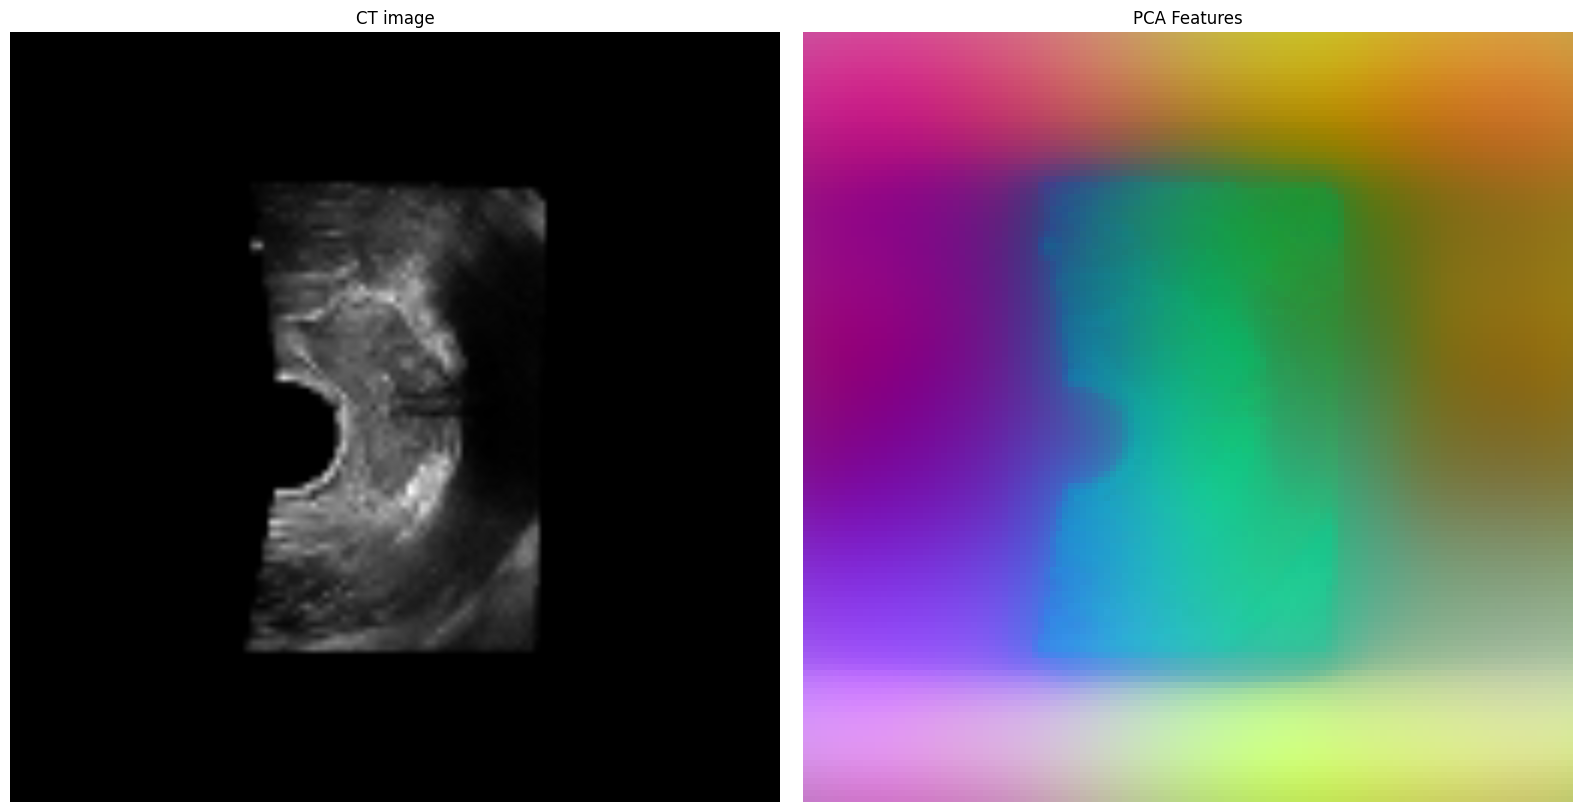

In [4]:
visualize_pca(resized_slice, model, resize_size)

In [32]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


def visualize_pca_layer(
    sample,
    model,
    input_size,
    layer_indices=[0, 1, 2],  # 要可视化的前面几层索引
    device='cuda'
):
    # --------------------------
    # 1. 定义钩子函数：适配列表类型的中间层输出
    # --------------------------
    intermediate_features = {}  # 存储中间层特征：{层索引: 特征张量}

    def hook_fn(layer_idx):
        """钩子函数：从列表中提取特征张量并保存"""
        def hook(module, input, output):
            # 关键修改：若输出是列表，取第一个元素（通常是核心特征）
            if isinstance(output, list):
                feat_tensor = output[0]  # 假设列表第一个元素是需要的特征张量
            else:
                feat_tensor = output  # 若不是列表，直接使用

            # 确保提取的是张量，再保存
            if isinstance(feat_tensor, torch.Tensor):
                intermediate_features[layer_idx] = feat_tensor.clone()
            else:
                raise TypeError(f"层{layer_idx}的输出不是张量，类型：{type(feat_tensor)}")
        return hook

    # 为指定层注册钩子
    hooks = []
    for idx in layer_indices:
        if 0 <= idx < len(model.blocks):
            hook = model.blocks[idx].register_forward_hook(hook_fn(idx))
            hooks.append(hook)
        else:
            raise ValueError(f"层索引{idx}超出模型总层数{len(model.blocks)}")

    # --------------------------
    # 2. 前向传播：触发钩子，捕获特征
    # --------------------------
    print("输入图像形状：", sample.shape)
    norm_sample = (sample - torch.min(sample)) / (torch.max(sample) - torch.min(sample) + 1e-8)

    with torch.no_grad():
        # 调用模型（钩子自动捕获中间层特征）
        _ = model(sample.unsqueeze(0).to(device), is_training=True)

    # 移除钩子
    for hook in hooks:
        hook.remove()

    # --------------------------
    # 3. 可视化每一层的PCA特征（复用原逻辑）
    # --------------------------
    patch_size = model.patch_embed.proj.kernel_size[0]  # 获取patch大小（如16）
    num_layers = len(layer_indices)

    # 创建子图：1行（原始图 + 每层特征图）
    fig, axes = plt.subplots(1, num_layers + 1, figsize=(6 * (num_layers + 1), 6))

    # 显示原始图像
    axes[0].imshow(np.transpose(norm_sample.numpy(), (1, 2, 0)), cmap="gray")
    axes[0].axis('off')
    axes[0].set_title("Original Image")

    # 逐层可视化PCA特征
    for i, layer_idx in enumerate(layer_indices):
        # 获取当前层的特征张量
        features = intermediate_features[layer_idx]  # (1, num_patches, feat_dim)

        # PCA降维（与原代码一致）
        pca = PCA(n_components=3, whiten=True)
        pca_features = pca.fit_transform(features.squeeze(0).cpu().detach().numpy())

        # 归一化与重塑
        norm_pca_feats = (pca_features - pca_features.min()) / (pca_features.max() - pca_features.min() + 1e-8)
        norm_pca_feats = norm_pca_feats.reshape(
            input_size // patch_size,
            input_size // patch_size,
            -1
        )

        # 显示特征图
        axes[i+1].imshow(norm_pca_feats)
        axes[i+1].axis('off')
        axes[i+1].set_title(f"Layer {layer_idx+1} (PCA Features)")

    plt.tight_layout()
    plt.show()

In [33]:
visualize_pca_layer(resized_slice, model, resize_size)

输入图像形状： torch.Size([3, 2048, 2048])


AttributeError: 'list' object has no attribute 'clone'

TypeError: 'PyDB' object is not callable